In [1]:
import pandas as pd
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
file_path = "../data/Song_Dataset.xlsx"
xls = pd.ExcelFile(file_path)
xls.sheet_names

['Song_Deatils', 'Node_Deatils', 'Data Dictionary']

In [3]:
song_df = pd.read_excel(file_path, sheet_name='Song_Deatils')
song_df.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode
0,"4,137",Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826.0,125,B,Major
1,"3,628",LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382.0,92,C#,Major
2,"3,520",vampire,Olivia Rodrigo,1,2023,June,30,1397,113,140003974,94,207,91,14,949.0,138,F,Major
3,"3,362",Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548.0,170,A,Major
4,"3,914",WHERE SHE GOES,Bad Bunny,1,2025,May,18,3133,50,303236322,84,133,87,15,425.0,144,A,Minor


In [4]:
song_df['Song_Id'] = song_df['Song_Id'].astype(str).str.strip()
song_df['Song_Id'] = song_df['Song_Id'].str.replace(',', '', regex=False)

song_df['Song_Id'].head() 


0    4137
1    3628
2    3520
3    3362
4    3914
Name: Song_Id, dtype: object

In [5]:
song_df['Song_Id'] = pd.to_numeric(song_df['Song_Id'], errors='coerce')

song_df['Song_Id'].head()

0    4137
1    3628
2    3520
3    3362
4    3914
Name: Song_Id, dtype: int64

In [6]:
song_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Song_Id               949 non-null    int64  
 1   track_name            949 non-null    object 
 2   artist(s)_name        949 non-null    object 
 3   artist_count          949 non-null    int64  
 4   released_year         949 non-null    int64  
 5   released_month        949 non-null    object 
 6   released_day          949 non-null    int64  
 7   in_spotify_playlists  949 non-null    int64  
 8   in_spotify_charts     949 non-null    int64  
 9   streams               949 non-null    object 
 10  in_apple_playlists    949 non-null    int64  
 11  in_apple_charts       949 non-null    int64  
 12  in_deezer_playlists   949 non-null    int64  
 13  in_deezer_charts      949 non-null    int64  
 14  in_shazam_charts      898 non-null    float64
 15  bpm                   9

In [7]:
song_df['streams'] = song_df['streams'].astype(str).str.replace(',', '', regex=False)
song_df['streams'] = pd.to_numeric(song_df['streams'], errors='coerce')

song_df[['streams']].head()

,streams
0,141381703.0
1,133716286.0
2,140003974.0
3,800840817.0
4,303236322.0


In [8]:
# Convert all to string first
song_df['released_month'] = song_df['released_month'].astype(str).str.strip()

# Create mapping
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Replace month names with numbers
song_df['released_month'] = song_df['released_month'].replace(month_map)
print(song_df['released_month'])

# Convert to numeric
song_df['released_month'] = pd.to_numeric(song_df['released_month'], errors='coerce')

song_df['released_month'].head(10)

0       7
1       3
2       6
3       8
4       5
       ..
944    11
945    10
946    11
947    10
948    11
Name: released_month, Length: 949, dtype: object


0    7
1    3
2    6
3    8
4    5
5    6
6    3
7    7
8    5
9    3
Name: released_month, dtype: int64

In [9]:
song_df.isnull().sum()

Song_Id                  0
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  1
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        51
bpm                      0
key                     96
mode                     0
dtype: int64

In [10]:
# Drop rows where streams is null
song_df = song_df.dropna(subset=['streams'])

# Fill Shazam charts with 0
song_df['in_shazam_charts'] = song_df['in_shazam_charts'].fillna(0)

# Optional: fill key
song_df['key'] = song_df['key'].fillna('Unknown')

# Check again
song_df.isnull().sum()

Song_Id                 0
track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
in_shazam_charts        0
bpm                     0
key                     0
mode                    0
dtype: int64

In [11]:
song_df.to_csv("../data/cleaned_song_data.csv", index=False)

In [12]:
audio_df = pd.read_excel(file_path, sheet_name='Node_Deatils')

audio_df.head()

,Song_Id,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,3788,81.0,97.0,77.0,75.0,0.0,35.0,3.0
1,4709,91.0,97.0,57.0,38.0,0.0,40.0,29.0
2,4087,86.0,97.0,80.0,36.0,0.0,9.0,6.0
3,2258,70.0,97.0,62.0,47.0,0.0,10.0,NaN
4,3911,70.0,NaN,59.0,55.0,0.0,27.0,12.0


In [13]:
audio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Song_Id             954 non-null    int64  
 1   danceability_%      906 non-null    float64
 2   valence_%           906 non-null    float64
 3   energy_%            907 non-null    float64
 4   acousticness_%      907 non-null    float64
 5   instrumentalness_%  906 non-null    float64
 6   liveness_%          906 non-null    float64
 7   speechiness_%       906 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 59.8 KB


In [14]:
audio_df.isnull().sum()

Song_Id                0
danceability_%        48
valence_%             48
energy_%              47
acousticness_%        47
instrumentalness_%    48
liveness_%            48
speechiness_%         48
dtype: int64

In [15]:
for col in audio_df.columns:
    if col != 'Song_Id':
        audio_df[col] = audio_df[col].fillna(audio_df[col].mean())

audio_df.isnull().sum()

Song_Id               0
danceability_%        0
valence_%             0
energy_%              0
acousticness_%        0
instrumentalness_%    0
liveness_%            0
speechiness_%         0
dtype: int64

In [16]:
song_ids_song = set(song_df['Song_Id'])
song_ids_audio = set(audio_df['Song_Id'])

print("Common IDs:", len(song_ids_song & song_ids_audio))
print("Only in Song:", len(song_ids_song - song_ids_audio))
print("Only in Audio:", len(song_ids_audio - song_ids_song))

Common IDs: 808
Only in Song: 4
Only in Audio: 8


In [17]:
# REMOVE DUPLICATES BEFORE MERGE

print("Before removing duplicates:", song_df.shape)

song_df = song_df.drop_duplicates(subset='Song_Id')

print("After removing duplicates:", song_df.shape)

print("Duplicate Song_Id count:", song_df['Song_Id'].duplicated().sum())

Before removing duplicates: (948, 18)
After removing duplicates: (812, 18)
Duplicate Song_Id count: 0


In [18]:
# left join to retain all songs and enrich them with audio features where available

merged_df = pd.merge(song_df, audio_df, on='Song_Id', how='left')

merged_df.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,263,45,10,826.0,125,B,Major,66.94702,89.0,83.0,26.994487,0.0,8.0,4.000000
1,3628,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,126,58,14,382.0,92,C#,Major,71.00000,61.0,74.0,7.000000,0.0,10.0,10.101545
2,3628,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,126,58,14,382.0,92,C#,Major,80.00000,24.0,65.0,26.994487,0.0,9.0,4.000000
3,3520,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,207,91,14,949.0,138,F,Major,51.00000,32.0,53.0,17.000000,0.0,31.0,6.000000
4,3362,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,207,125,12,548.0,170,A,Major,55.00000,58.0,72.0,11.000000,0.0,11.0,15.000000


In [19]:
# VERIFY DUPLICATES (CONFIRM)
audio_df['Song_Id'].value_counts().unique()

array([3, 2, 1])

In [20]:
audio_df['Song_Id'].value_counts().head(10)

Song_Id
2719    3
3215    3
3542    3
4422    3
2457    3
2942    3
4473    3
4991    3
2255    3
3026    3
Name: count, dtype: int64

In [21]:
audio_df = audio_df.groupby('Song_Id', as_index=False).mean()

audio_df.head()

,Song_Id,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,2000,71.0,41.0,31.00000,79.000000,0.0,10.0,5.0
1,2002,36.0,28.0,28.00000,81.000000,0.0,18.0,3.0
2,2010,57.0,55.0,64.24366,22.000000,0.0,8.0,4.0
3,2011,51.0,22.0,64.24366,1.000000,0.0,15.0,3.0
4,2012,82.0,88.0,76.00000,26.994487,0.0,12.0,9.0


In [22]:
merged_df = pd.merge(song_df, audio_df, on='Song_Id', how='left')

merged_df.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,263,45,10,826.0,125,B,Major,66.94702,89.0,83.0,26.994487,0.0,8.0,4.000000
1,3628,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,126,58,14,382.0,92,C#,Major,75.50000,42.5,69.5,16.997244,0.0,9.5,7.050773
2,3520,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,207,91,14,949.0,138,F,Major,51.00000,32.0,53.0,17.000000,0.0,31.0,6.000000
3,3362,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,207,125,12,548.0,170,A,Major,55.00000,58.0,72.0,11.000000,0.0,11.0,15.000000
4,3914,WHERE SHE GOES,Bad Bunny,1,2025,5,18,3133,50,303236322.0,84,133,87,15,425.0,144,A,Minor,65.00000,23.0,80.0,14.000000,63.0,11.0,6.000000


In [23]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Song_Id               812 non-null    int64  
 1   track_name            812 non-null    object 
 2   artist(s)_name        812 non-null    object 
 3   artist_count          812 non-null    int64  
 4   released_year         812 non-null    int64  
 5   released_month        812 non-null    int64  
 6   released_day          812 non-null    int64  
 7   in_spotify_playlists  812 non-null    int64  
 8   in_spotify_charts     812 non-null    int64  
 9   streams               812 non-null    float64
 10  in_apple_playlists    812 non-null    int64  
 11  in_apple_charts       812 non-null    int64  
 12  in_deezer_playlists   812 non-null    int64  
 13  in_deezer_charts      812 non-null    int64  
 14  in_shazam_charts      812 non-null    float64
 15  bpm                   8

In [24]:
audio_cols = [
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%'
]

for col in audio_cols:
    merged_df[col] = merged_df[col].fillna(merged_df[col].mean())

merged_df.isnull().sum()

Song_Id                 0
track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
in_shazam_charts        0
bpm                     0
key                     0
mode                    0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
dtype: int64

In [25]:
# Save final merged dataset
merged_df.to_csv("../data/final_merged_dataset.csv", index=False)

# Save cleaned audio dataset
audio_df.to_csv("../data/cleaned_audio_data.csv", index=False)

In [26]:
import os
os.listdir("../data")

['cleaned_audio_data.csv',
 'cleaned_song_data.csv',
 'final_merged_dataset.csv',
 'Song_Dataset.xlsx']

In [27]:
merged_df['streams'].describe()

count    8.120000e+02
mean     5.336384e+08
std      5.841859e+08
min      2.762000e+03
25%      1.399620e+08
50%      3.032263e+08
75%      7.035191e+08
max      3.703895e+09
Name: streams, dtype: float64

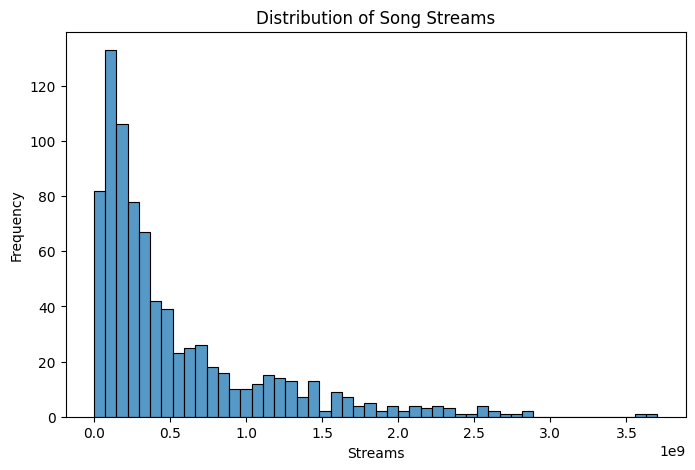

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(merged_df['streams'], bins=50)

plt.title("Distribution of Song Streams")
plt.xlabel("Streams")
plt.ylabel("Frequency")

plt.savefig("../reports/streams_distribution.png")
plt.show()

* The distribution of streams is highly right-skewed, indicating that a small number of songs contribute disproportionately to total streams, while the majority have moderate or low popularity
* Due to skewness, we will consider log transformation for better analytical stability in later steps

In [29]:

merged_df['log_streams'] = np.log1p(merged_df['streams'])

merged_df[['streams', 'log_streams']].head()

,streams,log_streams
0,141381703.0,18.766974
1,133716286.0,18.711231
2,140003974.0,18.757181
3,800840817.0,20.501173
4,303236322.0,19.530023


In [30]:
# Who are the top artists driving streams

top_songs = merged_df.sort_values(by='streams', ascending=False).head(10)

top_songs[['track_name', 'artist(s)_name', 'streams']]

,track_name,artist(s)_name,streams
54,Blinding Lights,The Weeknd,3.703895e+09
163,Shape of You,Ed Sheeran,3.562544e+09
83,Someone You Loved,Lewis Capaldi,2.887242e+09
552,Dance Monkey,Tones and I,2.864792e+09
40,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.808097e+09
147,One Dance,"Drake, WizKid, Kyla",2.713922e+09
81,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.665344e+09
126,Believer,Imagine Dragons,2.594040e+09
639,Closer,"The Chainsmokers, Halsey",2.591224e+09
47,Starboy,"The Weeknd, Daft Punk",2.565530e+09


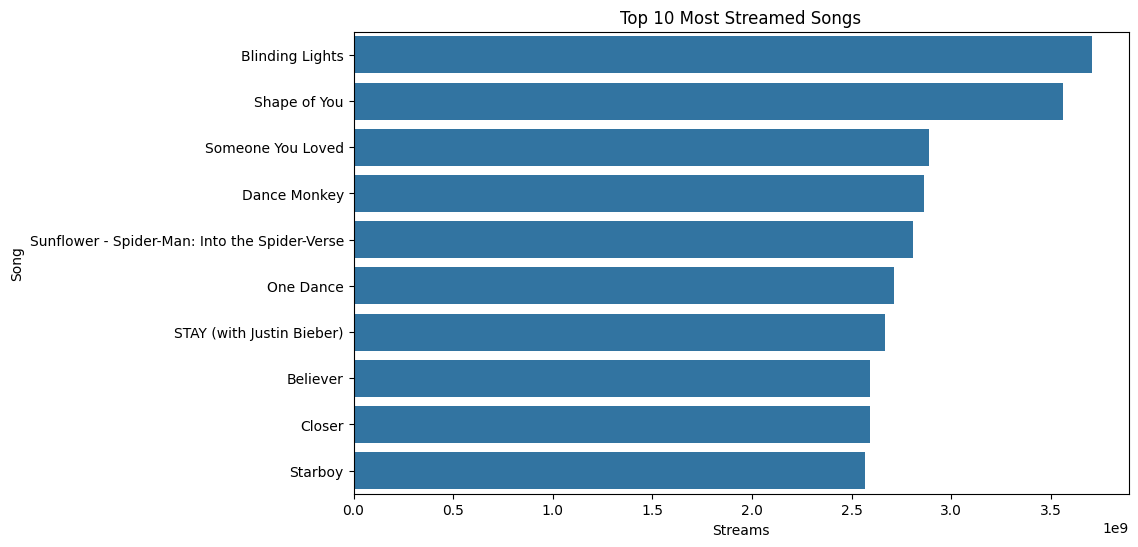

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_songs,
    x='streams',
    y='track_name'
)

plt.title("Top 10 Most Streamed Songs")
plt.xlabel("Streams")
plt.ylabel("Song")

plt.savefig("../reports/top_10_songs.png")
plt.show()

Top-performing songs are dominated by globally recognized artists, with collaboration tracks performing significantly well, indicating the importance of cross-audience reach

In [32]:
numeric_cols = [
    'streams', 'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts', 'bpm',
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%'
]

corr_matrix = merged_df[numeric_cols].corr()

corr_matrix['streams'].sort_values(ascending=False)

streams                 1.000000
in_spotify_playlists    0.800290
in_apple_playlists      0.775082
in_deezer_playlists     0.599497
in_apple_charts         0.333310
in_spotify_charts       0.240695
in_deezer_charts        0.236308
acousticness_%          0.013357
bpm                    -0.012879
valence_%              -0.016868
in_shazam_charts       -0.018794
energy_%               -0.032299
liveness_%             -0.036570
instrumentalness_%     -0.046447
danceability_%         -0.095011
speechiness_%          -0.116366
Name: streams, dtype: float64

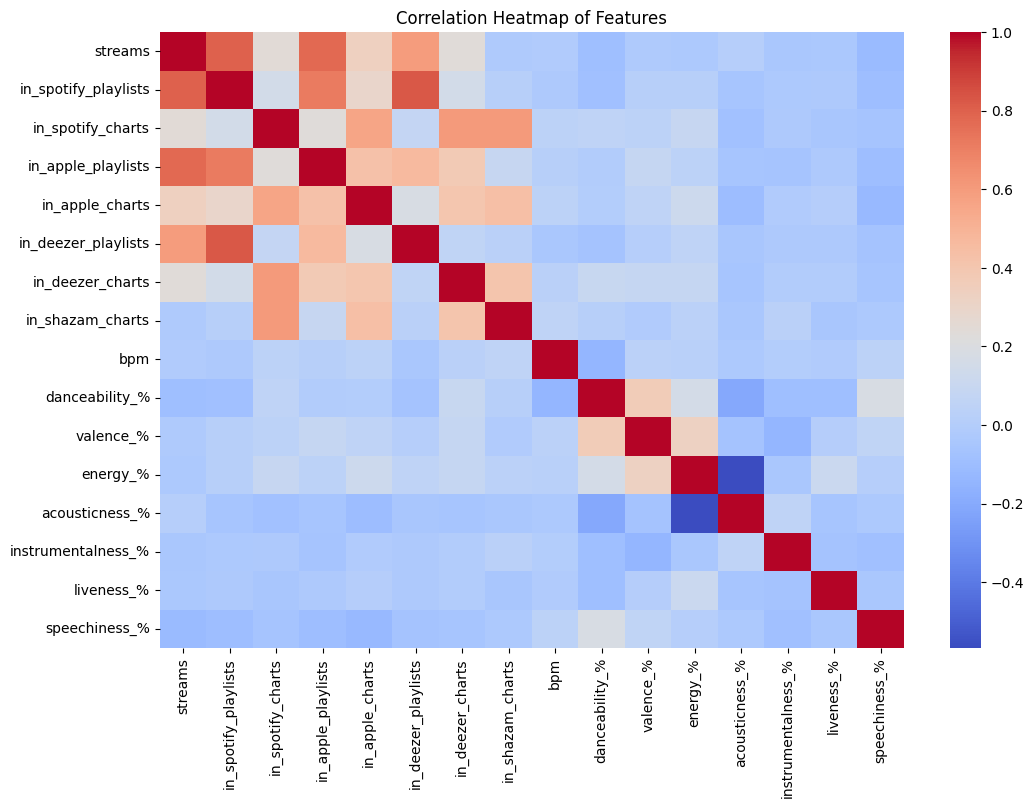

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)

plt.title("Correlation Heatmap of Features")

plt.savefig("../reports/correlation_heatmap.png")
plt.show()

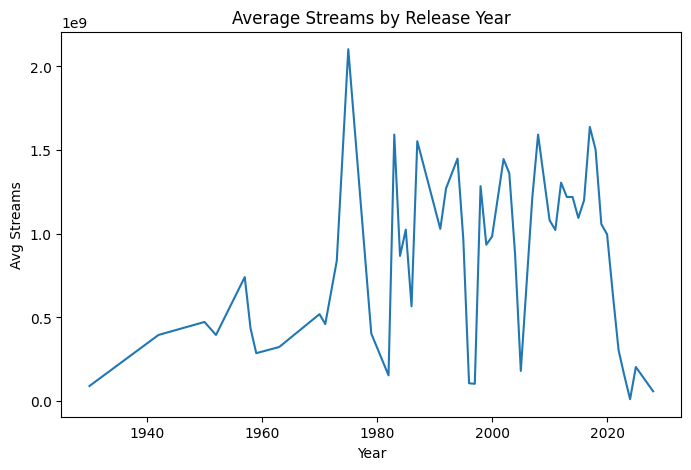

In [34]:
year_trend = merged_df.groupby('released_year')['streams'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(year_trend['released_year'], year_trend['streams'])

plt.title("Average Streams by Release Year")
plt.xlabel("Year")
plt.ylabel("Avg Streams")

plt.savefig("../reports/year_trend.png")
plt.show()

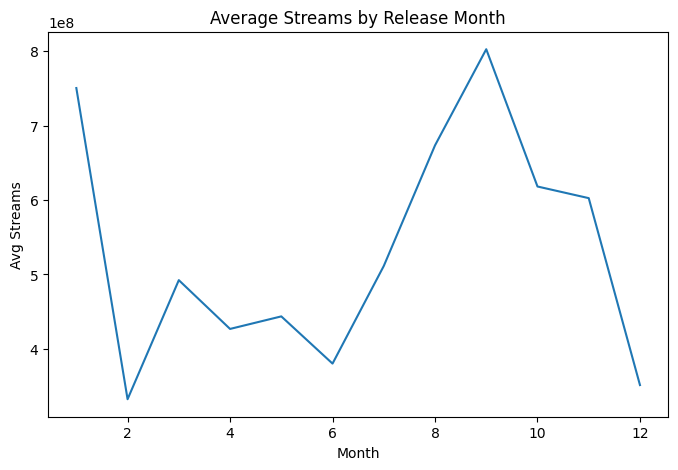

In [35]:
month_trend = merged_df.groupby('released_month')['streams'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(month_trend['released_month'], month_trend['streams'])

plt.title("Average Streams by Release Month")
plt.xlabel("Month")
plt.ylabel("Avg Streams")

plt.savefig("../reports/month_trend.png")
plt.show()

In [36]:
artist_streams = merged_df.groupby('artist(s)_name')['streams'].mean().reset_index()

top_artists = artist_streams.sort_values(by='streams', ascending=False).head(10)

top_artists

,artist(s)_name,streams
523,Tones and I,2.864792e+09
405,"Post Malone, Swae Lee",2.808097e+09
134,"Drake, WizKid, Kyla",2.713922e+09
241,"Justin Bieber, The Kid Laroi",2.665344e+09
494,"The Chainsmokers, Halsey",2.591224e+09
504,"The Weeknd, Daft Punk",2.565530e+09
185,Glass Animals,2.557976e+09
54,"Billie Eilish, Khalid",2.355720e+09
493,"The Chainsmokers, Coldplay",2.204081e+09
408,Queen,2.197011e+09


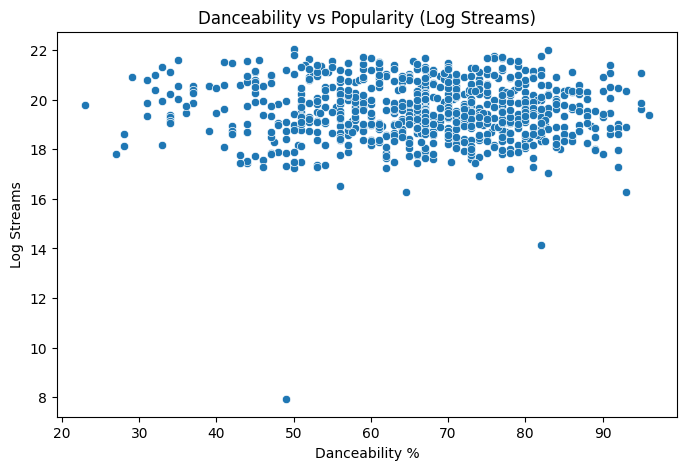

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged_df, x='danceability_%', y='log_streams')

plt.title("Danceability vs Popularity (Log Streams)")
plt.xlabel("Danceability %")
plt.ylabel("Log Streams")

plt.savefig("../reports/danceability_vs_streams.png")
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

features = [
    'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts',
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%'
]

X = merged_df[features]
y = merged_df['log_streams']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.23292336050380524


In [41]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,in_spotify_charts,0.008260
2,in_apple_playlists,0.003931
5,in_deezer_charts,0.001792
3,in_apple_charts,0.000517
11,instrumentalness_%,0.000357
0,in_spotify_playlists,0.000071
4,in_deezer_playlists,-0.000123
10,acousticness_%,-0.000474
6,in_shazam_charts,-0.001159
12,liveness_%,-0.001879


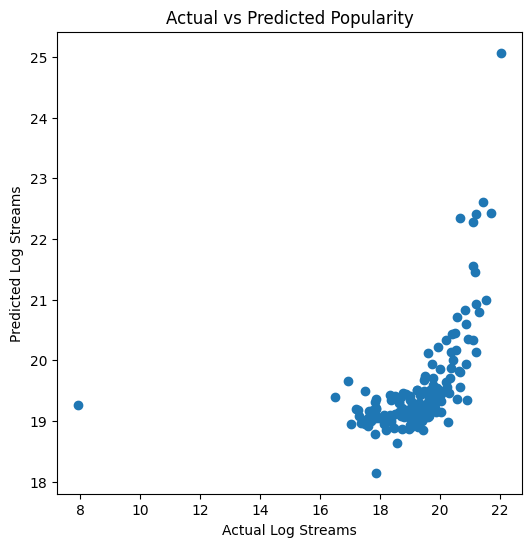

In [42]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Log Streams")
plt.ylabel("Predicted Log Streams")

plt.title("Actual vs Predicted Popularity")

plt.savefig("../reports/actual_vs_predicted.png")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest R²:", rf_r2)

Random Forest R²: 0.4924888836196154


In [44]:
rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

rf_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,in_spotify_playlists,0.678239
4,in_deezer_playlists,0.095418
1,in_spotify_charts,0.036129
2,in_apple_playlists,0.027028
6,in_shazam_charts,0.026051
3,in_apple_charts,0.025455
7,danceability_%,0.024133
9,energy_%,0.015975
8,valence_%,0.015754
10,acousticness_%,0.014457


I separated the dataset into logical entities—metadata, platform performance, and audio features—to enable scalable and modular analysis.

In [45]:
songs_master = merged_df[[
    'Song_Id', 'track_name', 'artist(s)_name', 'artist_count',
    'released_year', 'released_month', 'released_day',
    'bpm', 'key', 'mode'
]]

songs_master.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,bpm,key,mode
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,125,B,Major
1,3628,LALA,Myke Towers,1,2023,3,23,92,C#,Major
2,3520,vampire,Olivia Rodrigo,1,2023,6,30,138,F,Major
3,3362,Cruel Summer,Taylor Swift,1,2019,8,23,170,A,Major
4,3914,WHERE SHE GOES,Bad Bunny,1,2025,5,18,144,A,Minor


In [46]:
platform_metrics = merged_df[[
    'Song_Id',
    'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts'
]]

platform_metrics.head()

,Song_Id,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts
0,4137,553,147,43,263,45,10,826.0
1,3628,1474,48,48,126,58,14,382.0
2,3520,1397,113,94,207,91,14,949.0
3,3362,7858,100,116,207,125,12,548.0
4,3914,3133,50,84,133,87,15,425.0


In [47]:
audio_features = merged_df[[
    'Song_Id',
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%'
]]

audio_features.head()

,Song_Id,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4137,66.94702,89.0,83.0,26.994487,0.0,8.0,4.000000
1,3628,75.50000,42.5,69.5,16.997244,0.0,9.5,7.050773
2,3520,51.00000,32.0,53.0,17.000000,0.0,31.0,6.000000
3,3362,55.00000,58.0,72.0,11.000000,0.0,11.0,15.000000
4,3914,65.00000,23.0,80.0,14.000000,63.0,11.0,6.000000


In [48]:
popularity_metrics = merged_df[[
    'Song_Id',
    'streams', 'log_streams'
]]

popularity_metrics.head()

,Song_Id,streams,log_streams
0,4137,141381703.0,18.766974
1,3628,133716286.0,18.711231
2,3520,140003974.0,18.757181
3,3362,800840817.0,20.501173
4,3914,303236322.0,19.530023


In [49]:
# songs_master = songs_master.drop_duplicates(subset='Song_Id')

songs_master['Song_Id'].duplicated().sum()

np.int64(0)

In [50]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

load_dotenv()

username = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
database = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

In [51]:
songs_master.to_sql("songs_master", engine, if_exists="replace", index=False)
platform_metrics.to_sql("platform_metrics", engine, if_exists="replace", index=False)
audio_features.to_sql("audio_features", engine, if_exists="replace", index=False)
popularity_metrics.to_sql("popularity_metrics", engine, if_exists="replace", index=False)

812